# Admissão de candidatos ao curso de MBA

O conjunto de dados "MBA Admission" é composto por informações relacionadas aos candidatos que se inscreveram para um programa de MBA.

Cada entrada nesse conjunto possui atributos como gênero, nacionalidade, GPA, graduação, raça, pontuapção no GMAT, anos de experiência no trabalho, trabalho na indústria e status de admissão.



https://www.kaggle.com/datasets/taweilo/mba-admission-dataset?resource=download

**Objetivos:**

- Analisar os diferentes fatores que influenciam a admissão em um programa de MBA
- Identificar possíveis fators que influenciam a admissão em um programa de MBA
- Identificar possíveis padrões ou correlações entre esses atributos e a decisão de admissão

### Bibliotecas

In [ ]:
# Importando a biblioteca para manipulação de bases de dados
import pandas as pd

#Importando a biblioteca para manipulação algébrica
import numpy as np

# Configurar para não exibir warnings
import warnings
warnings.filterwarnings("ignore")

# Bibliotecas para a EDA
import missingno
import plotly.express as px
import plotly.graph_objects as go
import matplotlib.pyplot as plt
import seaborn as sns

!pip install summarytools
from summarytools import dfSummary

# teste de hipótese: t student
import scipy.stats as stats
from scipy.stats import ttest_ind

# Correlação de Spearman
from scipy.stats import spearmanr

# Correlação de Pearson
from scipy.stats import pearsonr

# teste de proporção: z
from statsmodels.stats.proportion import proportions_ztest

# Teste Qui-Quadrado de Independência
from scipy.stats import chi2_contingency

# Exibindo todas as colunas das bases de dados
pd.set_option('display.max_columns', None)

# Ajustando a configuração de exibição do Pandas para mostrar todo o conteúdo das colunas
pd.set_option('display.max_colwidth', None)

### DatraFrame

In [ ]:
# Leitura
df = pd.read_csv('mba.csv')
df.head()

,application_id,gender,international,gpa,major,race,gmat,work_exp,work_industry,admission
0,1,Female,False,3.30,Business,Asian,620.0,3.0,Financial Services,Admit
1,2,Male,False,3.28,Humanities,Black,680.0,5.0,Investment Management,NaN
2,3,Female,True,3.30,Business,NaN,710.0,5.0,Technology,Admit
3,4,Male,False,3.47,STEM,Black,690.0,6.0,Technology,NaN
4,5,Male,False,3.35,STEM,Hispanic,590.0,5.0,Consulting,NaN


# Informações gerais sobre o dataframe

Objetivo:

- Visualizar as primeiras 5 linhas do conjunto de dados para entender a estrutura.
- Usar .shape para verificar a quantidade de linhas e colunas
- Usar .info() para verificar valores e tipos de dados.
- Usar .columns para verificar os caracteres no nome das colunas

In [ ]:
print(f"O dataframe possui {df.shape[0]} linhas e {df.shape[1]} colunas.")

O dataframe possui 6194 linhas e 10 colunas.


In [ ]:
# Informações sobre todas as colunas do dataframe
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6194 entries, 0 to 6193
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   application_id  6194 non-null   int64  
 1   gender          6194 non-null   object 
 2   international   6194 non-null   bool   
 3   gpa             6194 non-null   float64
 4   major           6194 non-null   object 
 5   race            4352 non-null   object 
 6   gmat            6194 non-null   float64
 7   work_exp        6194 non-null   float64
 8   work_industry   6194 non-null   object 
 9   admission       1000 non-null   object 
dtypes: bool(1), float64(3), int64(1), object(5)
memory usage: 441.7+ KB


In [ ]:
df['international'] = df['international'].astype(object)  # Converter para tipo objeto

In [ ]:
print(df.columns)

Index(['application_id', 'gender', 'international', 'gpa', 'major', 'race',
       'gmat', 'work_exp', 'work_industry', 'admission'],
      dtype='object')


### Tratamento de dados


Objetivo:

- Padronizar valores de colunas e linhas.
-  Verificar os valores ausentes e duplicados
- Tratar os valores ausentes e duplicados, se necessário


In [ ]:
# Renomear colunas
df = df.rename(columns={'gender': 'genero', 'international': 'nacionalidade', 'major': 'graduacao', 'work_exp': 'experiencia', 'work_industry': 'trabalho_industria', 'race': 'raca', 'admission': 'admissao'})


In [ ]:
df['nacionalidade'] = df['nacionalidade'].astype(str).replace({
    'True': 'Internacional',
    'False': 'Nacional'
})

df['genero'] = df['genero'].astype(str).replace({
    'Male': 'Masculino',
    'Female': 'Feminino'
})

df['admissao'] = df['admissao'].astype(str).replace({
    'Admit': 'admitir',
    'Waitlist': 'lista de espera'
})

df.head()

,application_id,genero,nacionalidade,gpa,graduacao,raca,gmat,experiencia,trabalho_industria,admissao
0,1,Feminino,Nacional,3.30,Business,Asian,620.0,3.0,Financial Services,admitir
1,2,Masculino,Nacional,3.28,Humanities,Black,680.0,5.0,Investment Management,nan
2,3,Feminino,Internacional,3.30,Business,NaN,710.0,5.0,Technology,admitir
3,4,Masculino,Nacional,3.47,STEM,Black,690.0,6.0,Technology,nan
4,5,Masculino,Nacional,3.35,STEM,Hispanic,590.0,5.0,Consulting,nan


In [ ]:
valores_nulos = df.isnull().sum()
valores_nulos_data_frame = pd.DataFrame({'Nome da coluna': valores_nulos.index, 'Quantidade de valores nulos': valores_nulos.values})
valores_nulos_data_frame

,Nome da coluna,Quantidade de valores nulos
0,application_id,0
1,genero,0
2,nacionalidade,0
3,gpa,0
4,graduacao,0
5,raca,1842
6,gmat,0
7,experiencia,0
8,trabalho_industria,0
9,admissao,0


<Axes: >

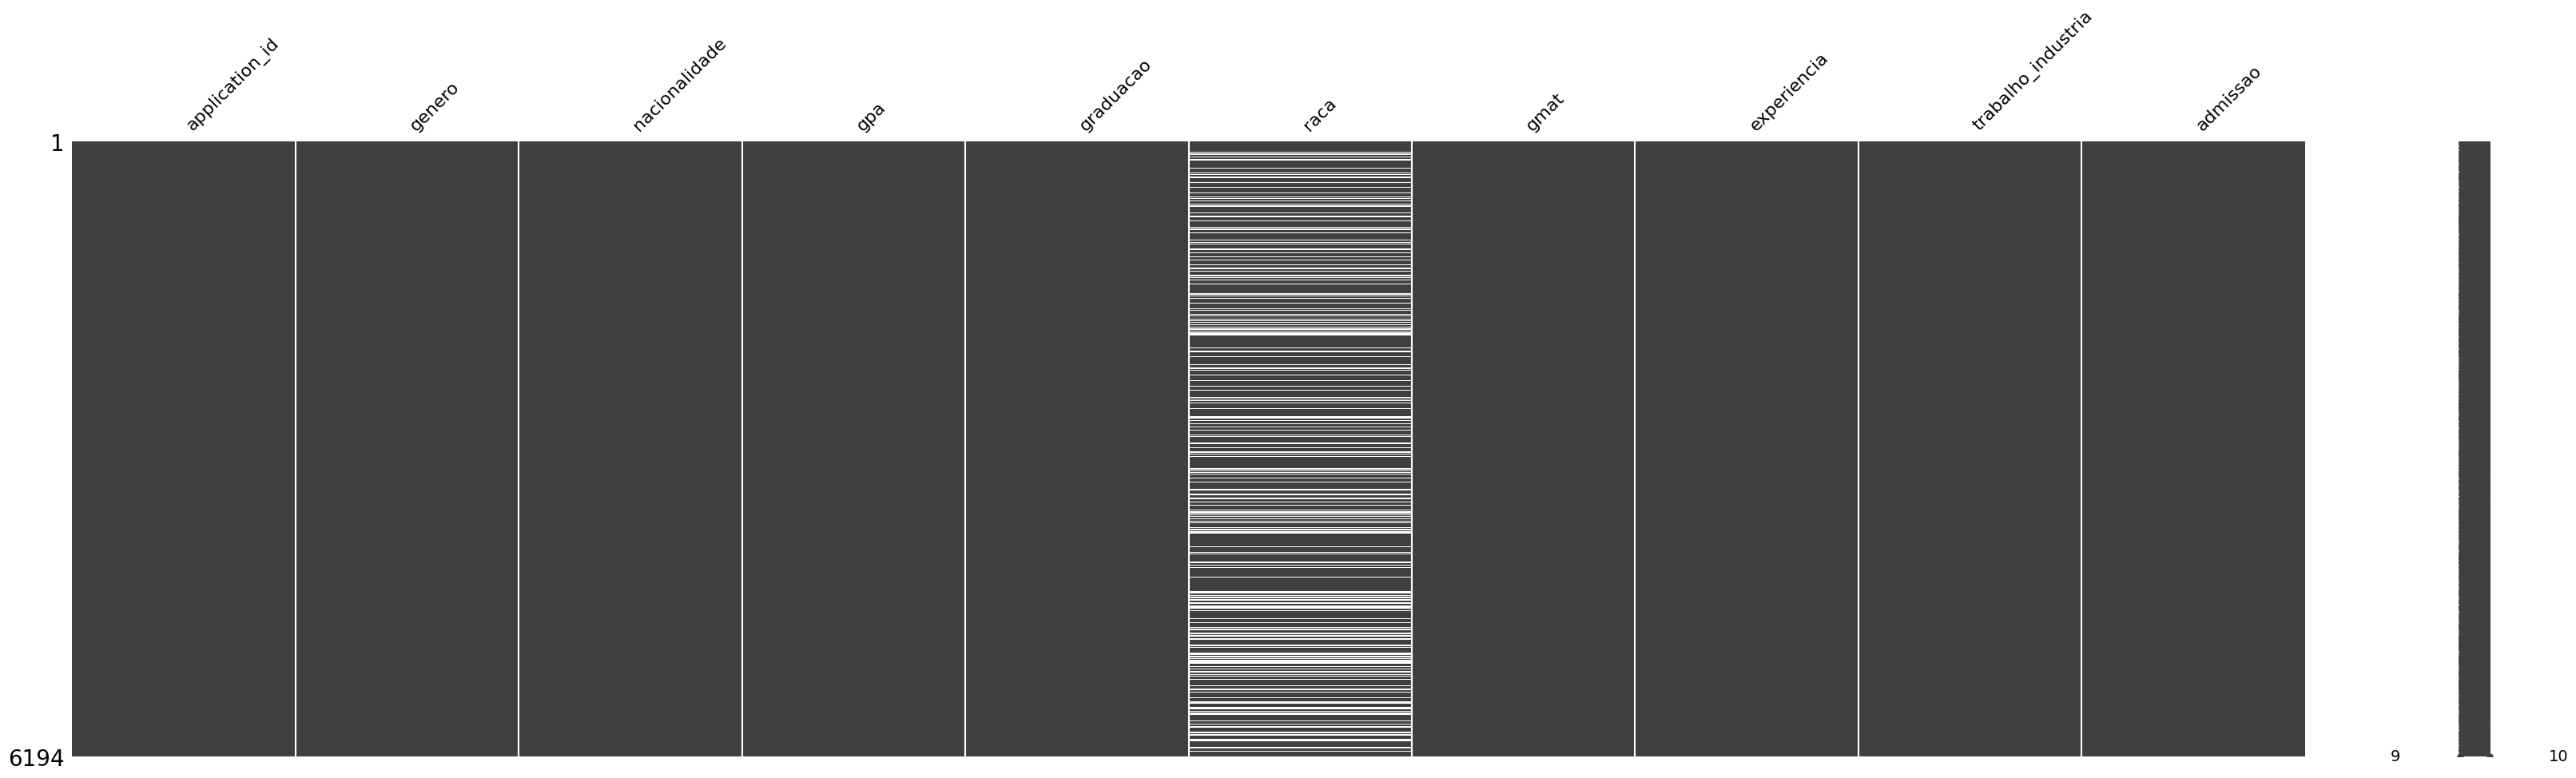

In [ ]:
# visualizando as colunas com dados faltantes
missingno.matrix(df,figsize=(40,10))

In [ ]:
# fazendo unpack de linhas e colunas
rows, columns = df.shape

# Percentual de dados faltantes por coluna
percentual_nan = ((df.isnull().sum()/rows) * 100).round(2)
percentual_nan

,0
application_id,0.00
genero,0.00
nacionalidade,0.00
gpa,0.00
graduacao,0.00
raca,29.74
gmat,0.00
experiencia,0.00
trabalho_industria,0.00
admissao,0.00


In [ ]:
# verificando se há linhas duplicadas
df[df.duplicated()]

,application_id,genero,nacionalidade,gpa,graduacao,raca,gmat,experiencia,trabalho_industria,admissao


In [ ]:
df.duplicated().sum()

0

### Valores das colunas

In [ ]:
# Definindo quantos valores diferentes existem em cada variável

contagem = pd.DataFrame(columns=['Variavel','Contagens_Distintas'])

for coluna in df.columns:
    temp = pd.DataFrame({'Variavel': [coluna], 'Contagens_Distintas': [df[coluna].value_counts().shape[0]]})
    contagem = pd.concat([contagem, temp], ignore_index = True)

contagem

,Variavel,Contagens_Distintas
0,application_id,6194
1,genero,2
2,nacionalidade,2
3,gpa,101
4,graduacao,3
5,raca,5
6,gmat,22
7,experiencia,9
8,trabalho_industria,14
9,admissao,3


In [ ]:
categorical_columns = df.select_dtypes(include=['object']).columns
for col in categorical_columns:
    print(f"\nUnique values in {col}:")
    print(df[col].value_counts())


Unique values in genero:
genero
Masculino    3943
Feminino     2251
Name: count, dtype: int64

Unique values in nacionalidade:
nacionalidade
Nacional         4352
Internacional    1842
Name: count, dtype: int64

Unique values in graduacao:
graduacao
Humanities    2481
STEM          1875
Business      1838
Name: count, dtype: int64

Unique values in raca:
raca
White       1456
Asian       1147
Black        916
Hispanic     596
Other        237
Name: count, dtype: int64

Unique values in trabalho_industria:
trabalho_industria
Consulting               1619
PE/VC                     907
Technology                716
Nonprofit/Gov             651
Investment Banking        580
Financial Services        451
Other                     421
Health Care               334
Investment Management     166
CPG                       114
Real Estate               111
Media/Entertainment        59
Retail                     33
Energy                     32
Name: count, dtype: int64

Unique values in admis

# Análise exploratória

Objetivo:

- Resumir os dados
- Identificar tendências e visualizar distribuições e padrões
- Entender melhor o conjunto de dados e destacar observações significativas.

In [ ]:
# Estátísticas descritivas do dataframe
df.describe()

,application_id,gpa,gmat,experiencia
count,6194.000000,6194.000000,6194.000000,6194.000000
mean,3097.500000,3.250714,651.092993,5.016952
std,1788.198115,0.151541,49.294883,1.032432
min,1.000000,2.650000,570.000000,1.000000
25%,1549.250000,3.150000,610.000000,4.000000
50%,3097.500000,3.250000,650.000000,5.000000
75%,4645.750000,3.350000,680.000000,6.000000
max,6194.000000,3.770000,780.000000,9.000000


In [ ]:
# Apresentando as funcionalidades da função dfSummary()
dfSummary(df)

No,Variable,Stats / Values,Freqs / (% of Valid),Graph,Missing
1,application_id[int64],Mean (sd) : 3097.5 (1788.2)min < med < max:1.0 < 3097.5 < 6194.0IQR (CV) : 3096.5 (1.7),"6,194 distinct values","<img src = ""data:image/png;base64, iVBORw0KGgoAAAANSUhEUgAAAKoAAABGCAYAAABc8A97AAAAOnRFWHRTb2Z0d2FyZQBNYXRwbG90bGliIHZlcnNpb24zLjEwLjAsIGh0dHBzOi8vbWF0cGxvdGxpYi5vcmcvlHJYcgAAAAlwSFlzAAAPYQAAD2EBqD+naQAAAcZJREFUeJzt10FOwmAQQOH5GyUgpA0hwgG8AUsO4WE9BCdg4cYVOxLSlFAxGqwnACk16kvet22nM4sXElLTNCH9d9lfHyBd4ua7F1JKg4joXfn9LCI+r5ztOk/dTb276/x70zSHUw/PhppSGkwmk8c8z8dttx6Px9u6rh9Go9FLlmUfvzlP3U29+yfmd7tdmVJ6OhXrd7+ovTzPx4vF4lAUxVubxev1erxare7n8/nzbDYr28x2nafupt7ddb6qqv5yuRxvt9teRFwVakREFEXxNp1OX9ssL8tyEBExHA5bz3adp+6m3v0T8xExOPfQP1NCMFQhGKoQDFUIhioEQxWCoQrBUIVgqEIwVCEYqhAMVQiGKgRDFYKhCsFQhWCoQjBUIRiqEAxVCIYqBEMVgqEKwVCFYKhCMFQhGKoQDFUIhioEQxWCoQrBUIVgqEIwVCEYqhAMVQiGKgRDFYKhCsFQhWCoQjBUIRiqEAxVCIYqBEMVgqEKwVCFYKhCMFQhGKoQDFUIhioEQxWCoQrBUIVgqEIwVCEYqhAMVQiGKgRDFYKhCuHmkpeqquq3/fB+v+9HRNR13d9sNne/OU/dTb276/wlfX0BkpY55nO5980AAAAASUVORK5CYII="">",0(0.0%)
2,genero[object],1. Masculino2. Feminino,"3,943 (63.7%)2,251 (36.3%)","<img src = ""data:image/png;base64, iVBORw0KGgoAAAANSUhEUgAAAJsAAAAuCAYAAAA/ZmtKAAAAOnRFWHRTb2Z0d2FyZQBNYXRwbG90bGliIHZlcnNpb24zLjEwLjAsIGh0dHBzOi8vbWF0cGxvdGxpYi5vcmcvlHJYcgAAAAlwSFlzAAAPYQAAD2EBqD+naQAAATlJREFUeJzt20GKg0AURdFnI6EzUURwMS6iF9uLcDci1iAJmVQPeg2+Sv26ZwU/5CIk+LqcswCHTtJd0q30IZAkvXPOz9JHXKWf5/lnGIap9CGQUkpH13W/UYPrh2GY1nV9juP4Kn1My87z/N62bdr3/SYpZmySNI7ja1mWR+ljoHvpA670VfoAtIPYYENssCE22BAbbIgNNsQGG2KDDbHBhthgQ2ywITbYEBtsiA02xAabXvp/ca/0Ia1r4TvoU0rHtm2Tgr+4V4OU0iHpXfqOqzB4+SyhBy8dUz64tPBkC/20qEn4KV/0eVxNQk/5WpjH1aSFKR+/sj8Ef+rChthgQ2ywITbYEBtsiA02xAYbYoMNscGG2GBDbLAhNtgQG2yIDTbEBpvQU76on6tW4ad80edxNWHwAps/Cltq34QLVTQAAAAASUVORK5CYII="">",0(0.0%)
3,nacionalidade[object],1. Nacional2. Internacional,"4,352 (70.3%)1,842 (29.7%)","<img src = ""data:image/png;base64, iVBORw0KGgoAAAANSUhEUgAAAJsAAAAuCAYAAAA/ZmtKAAAAOnRFWHRTb2Z0d2FyZQBNYXRwbG90bGliIHZlcnNpb24zLjEwLjAsIGh0dHBzOi8vbWF0cGxvdGxpYi5vcmcvlHJYcgAAAAlwSFlzAAAPYQAAD2EBqD+naQAAATpJREFUeJzt28GJwzAURdGvYEKykTAGF+MiptgUoW6MsRaTkI1mkQJiz+KJj+6p4ENuAjF+odZqgEIws7uZXVsfglPetdZn6yPOGqZp+okxjq0PwXGllC2E8PAW3BBjHJdleaaUXq2PwXf7vt9yzuO6rlcz8xWbmVlK6TXP82/rY3DYvfUB/3FpfQD6QWyQITbIEBtkiA0yxAYZYoMMsUGG2CBDbJAhNsgQG2SIDTLEBhlig8xg9nkhr/UhOMbzZzWUUrac82hOX8jrUSllM7N36zvOYvDik8vBS2DKBxXPv2wuv909czvl8zpn65nLKZ/nOVvPPE/5+PfsDA91IUNskCE2yBAbZIgNMsQGGWKDDLFBhtggQ2yQITbIEBtkiA0yxAYZYoOMyymft3vx4XbK53XO1jMGL5D5Awpbat9XXYz8AAAAAElFTkSuQmCC"">",0(0.0%)
4,gpa[float64],Mean (sd) : 3.3 (0.2)min < med < max:2.6 < 3.2 < 3.8IQR (CV) : 0.2 (21.5),101 distinct values,"<img src = ""data:image/png;base64, iVBORw0KGgoAAAANSUhEUgAAAKoAAABGCAYAAABc8A97AAAAOnRFWHRTb2Z0d2FyZQBNYXRwbG90bGliIHZlcnNpb24zLjEwLjAsIGh0dHBzOi8vbWF0cGxvdGxpYi5vcmcvlHJYcgAAAAlwSFlzAAAPYQAAD2EBqD+naQAAAoZJREFUeJzt3buO2kAUgOEz8UIMJLYACTpeIFIKSvq0edg8QgqK1LwBDUIgBMJZC2OcaqNdiVywMZwz/F8/yxS/tAyaiyuKQgDt3t17AsD/eLr3BHzknGuJSLPk8ENRFM/XnI8PCPXKnHOtfr//NYqibpnxu91u45z7RqxvEer1NaMo6k4mk+c4jtNLBm6323A6nXbX63VTRAj1FUKtSRzH6WAw+FliaOvqk/EAiymYQKgwgVBhAqHCBEKFCYQKEwgVJhAqTCBUmECoMIFQYQKhwgRChQnsnvqDCpufo9Pp1Lj2fB4doZ5RZfNzlmVhnuef0jT9LiJltvnhDEI9r/Tm5/l83p3NZu3j8RjUNblHRKh/UWbz82azYeNzDVhMwQRChQn861cmz/OGiETOubJ/wsvj1oSqSJIkjSzLPo9GoyAIgosWcS98PW5NqIocDoenMAzb4/E4HQ6Hm0vH+3zcmlAV6nQ6ZY9ai3h63JrFFEwgVJhAqDCBUGECocIEQoUJhAoTCBUmECpMIFSYQKgwgVBhAqHCBEKFCYQKE7zdj1rx9TwukVDGy1Crvp7HJRL6eBmqVLhAQoRLJDTyNVQRKf96HpdI6MNiCiYQKkwgVJjg9XfUR1TxphW1t6wQqkeq3rSi+ZYVQvVIlZtWtN+yQqgeqnDTitqf5VhMwQRChQmEChMIFSYQKkwgVJhAqDBB9e+oPPOIF2pD5ZlHvKY2VOGZx5vT/HSQ5lBFhGceb0X700HqQ8VtaH86iFDxhtang2oNlbP1j6XOTdv/DNU5F4rI+xIfHPZ6vS9xHH8oMfb3yn21Wv24dOx+vw9FRJIkCZfLZfuW4+819t6fvVgsPta5afsX71dRffvq/NgAAAAASUVORK5CYII="">",0(0.0%)
5,graduacao[object],1. Humanities2. STEM3. Business,"2,481 (40.1%)1,875 (30.3%)1,838 (29.7%)","<img src = ""data:image/png;base64, iVBORw0KGgoAAAANSUhEUgAAAJsAAABFCAYAAABdVZTTAAAAOnRFWHRTb2Z0d2FyZQBNYXRwbG90bGliIHZlcnNpb24zLjEwLjAsIGh0dHBzOi8vbWF

ANÁLISE DAS INFORMAÇÕES GERAIS DO DATAFRAME:

Descriação das colunas

- application_id: Um identificador exclusivo atribuído a cada inscrição dos candidatos.
- gênero: O gênero do candidato (Masculino, Feminino).
- Nacionalidade: Indica se o candidato é um estudante internacional ou nacional.
- gpa: Média de notas do candidato (em uma escala de 4,0).
- graduação: A graduação do candidato (por exemplo, Negócios, Humanidades).
- raça: Origem racial do candidato (por exemplo, Branco, Negro, Asiático, Hispânico, Outro). Para estudantes internacionais, este campo pode ser nulo.
- gmat: Pontuação GMAT do candidato (pontuação máxima: 800).
- experiência profissional: O número de anos de experiência de trabalho (medido em anos).
- trabalho na indústria: O setor onde o candidato obteve sua experiência de trabalho anterior (por exemplo, Consultoria, Finanças, Tecnologia, etc.).
- admissão: Status de admissão do candidato (Admitir, Lista de espera, Nulo).

Valores nulos, duplicados e diferentes:

- Os valores nulos concentram-se nas colunas "raça" (29,74%) e "admissão" (83,86%)
- Não há linhas duplicadas
-  As colunas que contém maior quantidade de valores difentes são: id dos candidatos (6.194), notas de GPA (101) e GMAT (22) e tipo de trabalho na indústria

### 1. Qual é a distribuição de gênero, nacionalidade, graduação principal e raça?

In [ ]:
# Definir as colunas categóricas
colunas_categoricas = ['genero', 'graduacao', 'raca', 'trabalho_industria', 'admissao', 'nacionalidade']

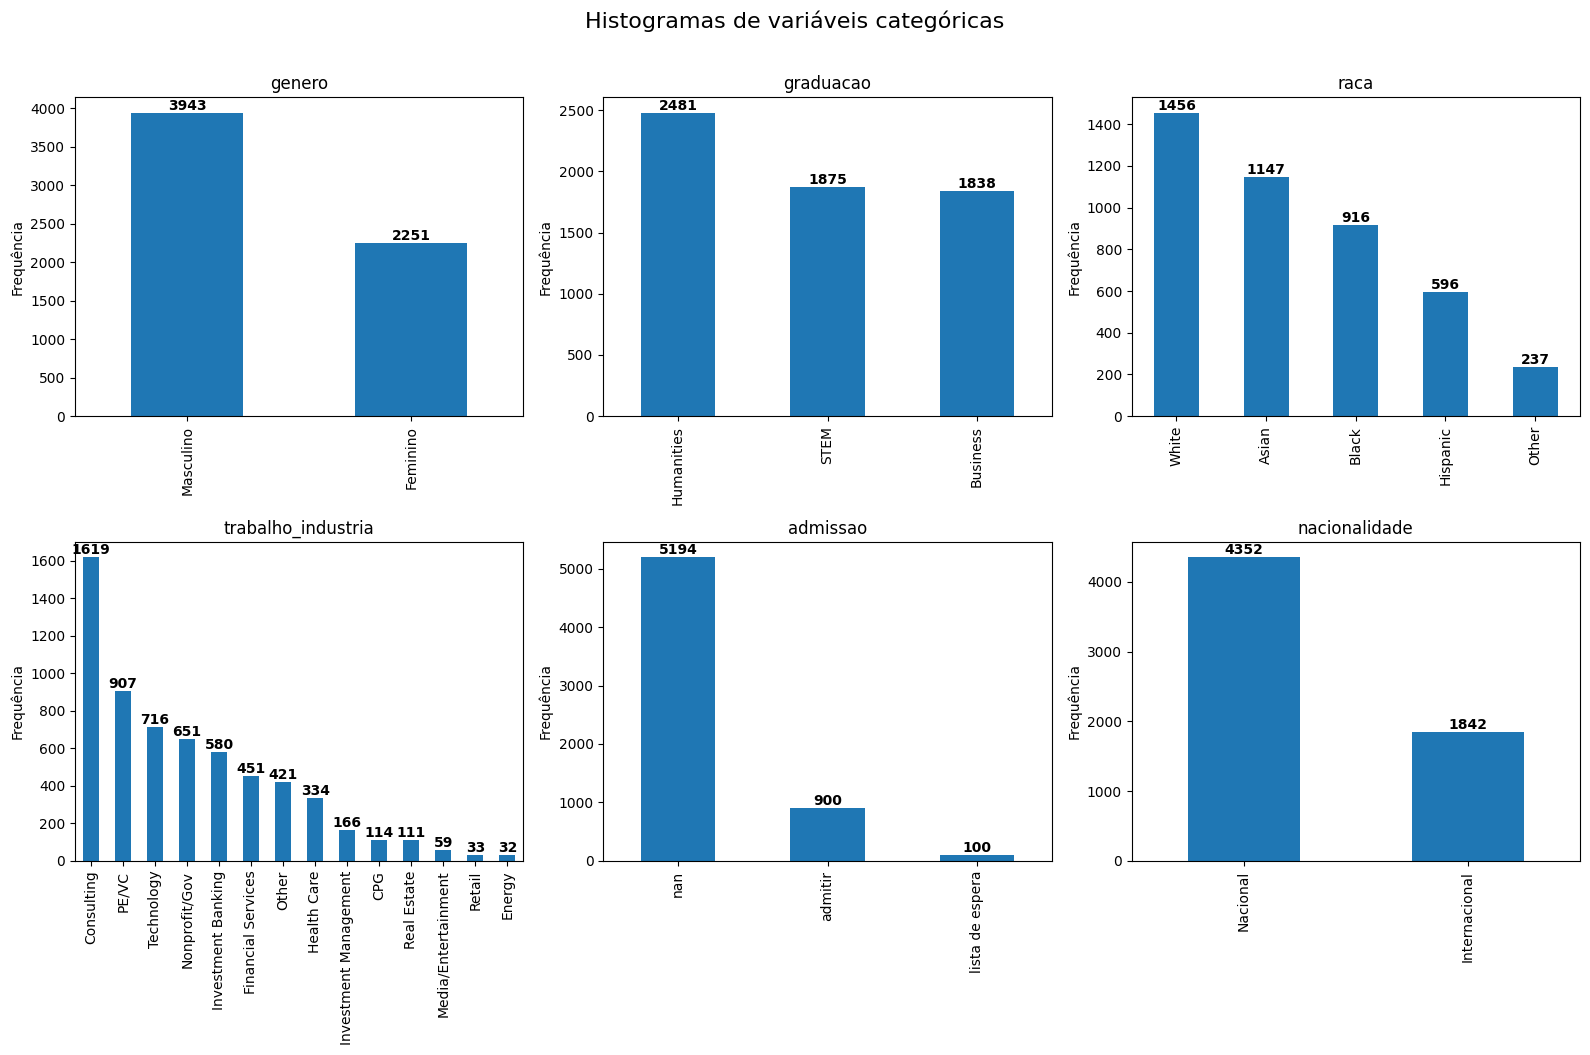

In [ ]:
# Criar subplots
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(16, 10))  # Ajuste conforme o número de colunas
axes = axes.flatten()

# Criar histogramas para cada coluna categórica
for i, coluna in enumerate(colunas_categoricas):
    if coluna in df.columns:
        counts = df[coluna].value_counts()
        counts.plot(kind='bar', ax=axes[i], color='#1f77b4')  # Adicionar cor personalizada

        axes[i].set_title(f'{coluna}')
        axes[i].set_xlabel('')
        axes[i].set_ylabel('Frequência')

        # Adicionar rótulos de valor acima das barras
        for p in axes[i].patches:
            axes[i].annotate(f'{int(p.get_height())}',
                             (p.get_x() + p.get_width() / 2, p.get_height()),
                             ha='center', va='bottom', fontsize=10, color='black', fontweight='bold')

# Ajustar layout
plt.tight_layout()
plt.suptitle('Histogramas de variáveis categóricas', fontsize=16, y=1.05)  # Título geral
plt.show()

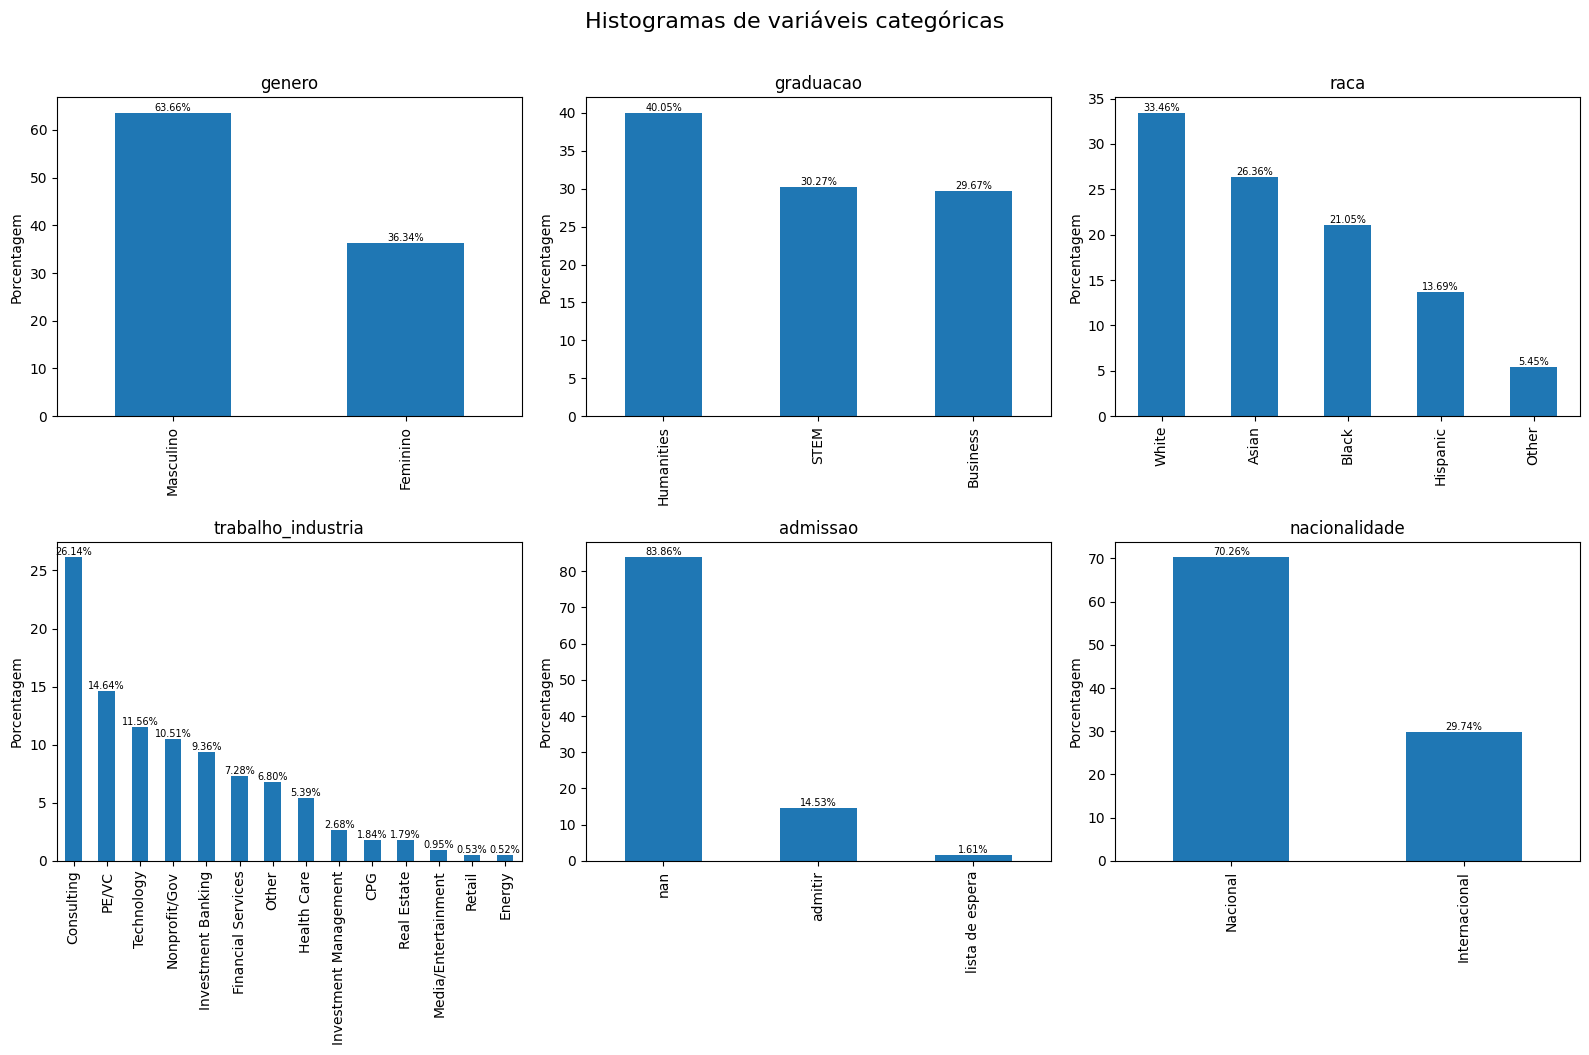

In [ ]:
# Criar subplots
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(16, 10))  # Ajuste conforme o número de colunas
axes = axes.flatten()

# Criar histogramas para cada coluna categórica
for i, coluna in enumerate(colunas_categoricas):
    if coluna in df.columns:
        counts = df[coluna].value_counts(normalize=True) * 100  # Calcular percentuais
        counts.plot(kind='bar', ax=axes[i], color='#1f77b4')  # Adicionar cor personalizada

        axes[i].set_title(f'{coluna}')
        axes[i].set_xlabel('')
        axes[i].set_ylabel('Porcentagem')

        # Adicionar rótulos de valor percentual acima das barras
        for p in axes[i].patches:
            axes[i].annotate(f'{p.get_height():.2f}%',  # Formato com duas casas decimais
                             (p.get_x() + p.get_width() / 2, p.get_height()),
                             ha='center', va='bottom', fontsize=7, color='black')

# Ajustar layout
plt.tight_layout()
plt.suptitle('Histogramas de variáveis categóricas', fontsize=16, y=1.05)  # Título geral
plt.show()


ANÁLISE DA DISTRIBUIÇÃO DAS VARIÁVEIS CATEGÓRICAS

- A maioria dos candidatos são do gênero masculino, possuem graduação em humanidades, são da raça branca, atuam no setor de consultoria e possuem nacionalidade local.

- 14,53% dos candidatos serão admitidos e 1,16% estão na lista de espera



### 2. Qual é a proporção de candidatos internacionais que foram admitidos? E dos candidatos locais?

In [ ]:
# Agrupar pelos valores de 'international' e 'admissão' para contar os IDs únicos
inter_adim = (
    df.groupby(['nacionalidade', 'admissao'])
    .agg(qtd_id=('application_id', 'nunique'))  # Contar IDs únicos
    .reset_index()
)

# Calcular o percentual de 'qtd_id'
inter_adim['qtd_id (%)'] = (inter_adim['qtd_id'] / inter_adim['qtd_id'].sum()) * 100
inter_adim['qtd_id (%)'] = inter_adim['qtd_id (%)'].round(2)  # Arredondar para 2 casas decimais

# Exibir o novo DataFrame
inter_adim

,nacionalidade,admissao,qtd_id,qtd_id (%)
0,Internacional,admitir,278,4.49
1,Internacional,lista de espera,30,0.48
2,Internacional,nan,1534,24.77
3,Nacional,admitir,622,10.04
4,Nacional,lista de espera,70,1.13
5,Nacional,nan,3660,59.09


In [ ]:
# Filtrar os candidatos admitidos
admitidos = inter_adim[inter_adim['admissao'] == 'admitir']
admitidos

,nacionalidade,admissao,qtd_id,qtd_id (%)
0,Internacional,admitir,278,4.49
3,Nacional,admitir,622,10.04


In [ ]:
# Criando o gráfico de barras verticais
fig_admitidos = px.bar(
    admitidos,
    x='nacionalidade',  # Agora o gênero estará no eixo X
    y='qtd_id (%)',  # O percentual ficará no eixo Y
    text='qtd_id (%)',  # Exibir os valores percentuais dentro das barras
    title='Proporção de candidatos admitidos por nacionalidade',
    labels={'nacionalidade': 'Nacionalidade', 'qtd_id (%)': 'Nº candidatos (%)'},
    color='nacionalidade'  # Colorir as barras por gênero
)

# Ajustar a posição do texto para fora das barras
fig_admitidos.update_traces(
    textposition='outside'  # Valores acima das barras
)

# layout
fig_admitidos.update_layout(
    xaxis_title='Nacionalidade',
    yaxis_title='Nº candidatos (%)',
    plot_bgcolor="white",
    bargap=0.2  # Ajustar o espaçamento entre as barras
)

# Exibir o gráfico
fig_admitidos.show()

### 3. Qual é a média de GPA para candidatos internacionais? E do GMAT? Como elas se diferem quando comparamos com os candidatos nacionais?

In [ ]:
# Criar um novo DataFrame 'gmat_gpa' sem modificar 'df'
gmat_gpa = df.groupby('nacionalidade')[['gmat', 'gpa']].mean().round(2).reset_index()

# Renomear as colunas para 'gmat_media' e 'gpa_media'
gmat_gpa.rename(columns={'gmat': 'gmat_media', 'gpa': 'gpa_media'}, inplace=True)

# Exibir o DataFrame resultante
gmat_gpa


,nacionalidade,gmat_media,gpa_media
0,Internacional,649.97,3.24
1,Nacional,651.57,3.25


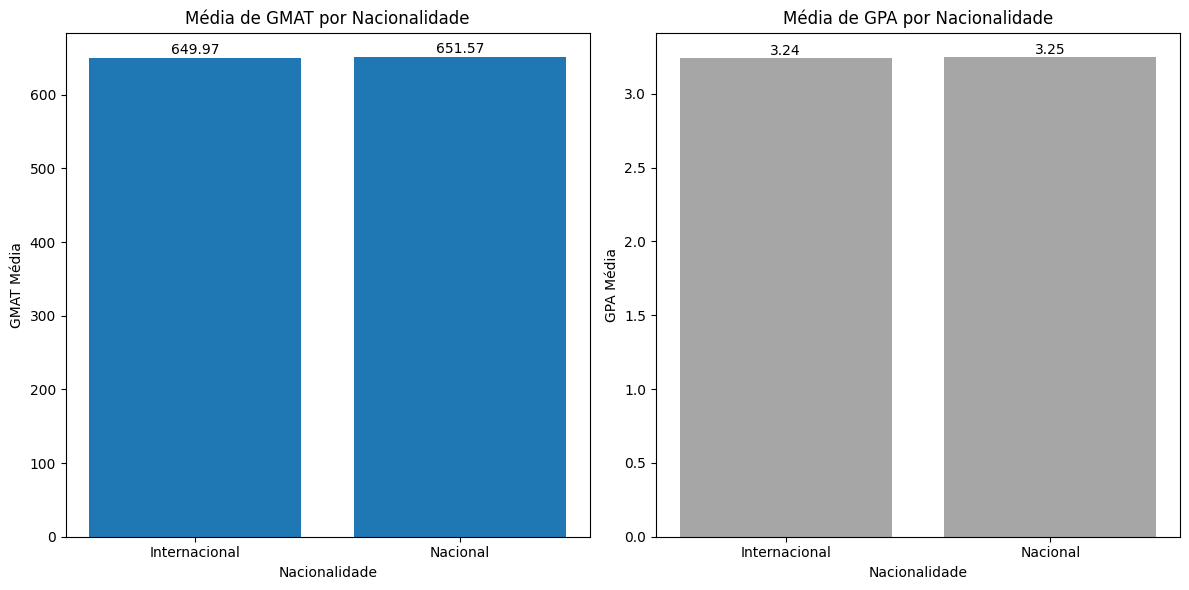

In [ ]:
# Criar a figura e os eixos dos gráficos
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 6))  # Criar dois gráficos lado a lado

# Converter os valores de 'international' para strings, se necessário
gmat_gpa['nacionalidade'] = gmat_gpa['nacionalidade'].astype(str)

# Criar os índices numéricos para o eixo X
x_labels = gmat_gpa['nacionalidade'].unique()  # Obter os rótulos únicos
x_pos = np.arange(len(x_labels))  # Criar posições para as barras

# Gráfico 1: GMAT Média
axes[0].bar(x_pos, gmat_gpa['gmat_media'], color='#1f77b4')
axes[0].set_title('Média de GMAT por Nacionalidade')
axes[0].set_xlabel('Nacionalidade')
axes[0].set_ylabel('GMAT Média')
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(x_labels)  # Substituir os índices numéricos pelos nomes reais

# Adicionar valores nas barras do gráfico GMAT
for i, v in enumerate(gmat_gpa['gmat_media']):
    axes[0].text(i, v + 5, f'{v:.2f}', ha='center', fontsize=10)

# Gráfico 2: GPA Média
axes[1].bar(x_pos, gmat_gpa['gpa_media'], color='#a6a6a6')
axes[1].set_title('Média de GPA por Nacionalidade')
axes[1].set_xlabel('Nacionalidade')
axes[1].set_ylabel('GPA Média')
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(x_labels)  # Substituir os índices numéricos pelos nomes reais

# Adicionar valores nas barras do gráfico GPA
for i, v in enumerate(gmat_gpa['gpa_media']):
    axes[1].text(i, v + 0.02, f'{v:.2f}', ha='center', fontsize=10)

# Ajustar o layout para evitar sobreposição
plt.tight_layout()

# Exibir os gráficos
plt.show()


### 4. Comparando os candidatos internacionais e nacionais, como é a distribuição das notas que foram estimadas a média na questão anterior?

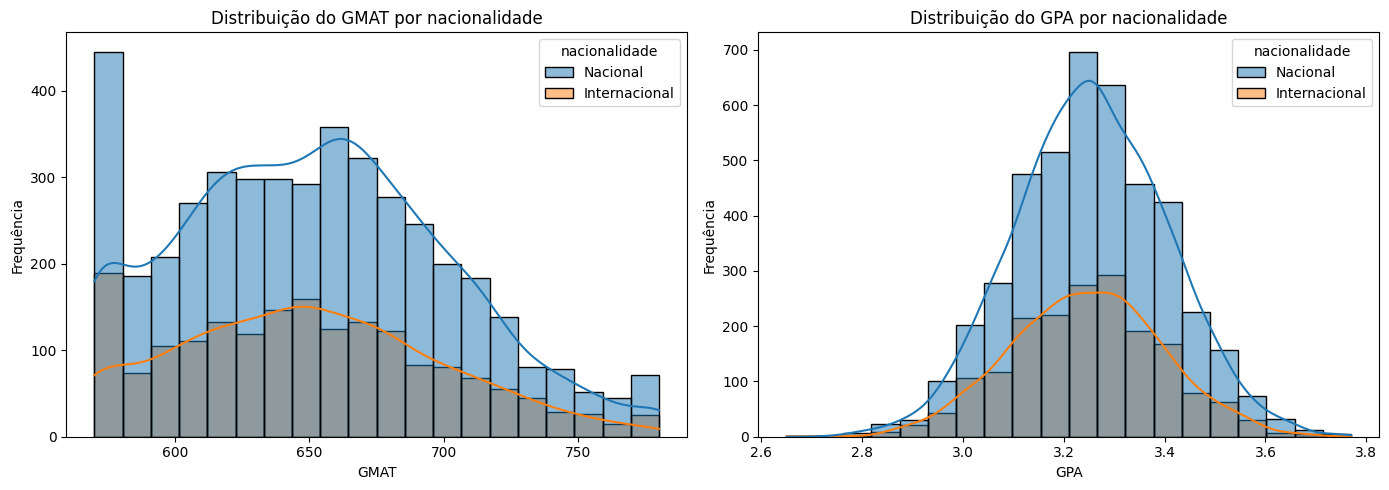

In [ ]:
# Criar a figura com 2 subgráficos lado a lado
fig, axes = plt.subplots(1, 2, figsize=(14, 5))  # 1 linha, 2 colunas

# Histograma do GMAT por Internacional
sns.histplot(data=df, x='gmat', hue='nacionalidade', kde=True, bins=20, ax=axes[0])
axes[0].set_title('Distribuição do GMAT por nacionalidade')
axes[0].set_xlabel('GMAT')
axes[0].set_ylabel('Frequência')

# Histograma do GPA por Internacional
sns.histplot(data=df, x='gpa', hue='nacionalidade', kde=True, bins=20, ax=axes[1])
axes[1].set_title('Distribuição do GPA por nacionalidade')
axes[1].set_xlabel('GPA')
axes[1].set_ylabel('Frequência')

# Ajustar layout
plt.tight_layout()
plt.show()


In [ ]:
# Criando o boxplot corretamente
fig_df_gpa = px.box(
    df,
    x='nacionalidade',  # Nacionalidade no eixo X
    y='gpa',  # GPA no eixo Y
    title='Distribuição do GPA dos Candidatos Admitidos',
    labels={'nacionalidade': 'Internacional', 'gpa': 'GPA'},
    color='nacionalidade',  # Diferenciar as caixas por cor
    boxmode="overlay"  # Evita sobreposição excessiva
)

# Ajustar o layout para um estilo mais próximo ao da imagem anterior
fig_df_gpa.update_traces(
    jitter=0.3,  # Espalhar levemente os pontos para visualização
    pointpos=0,  # Posicionar pontos diretamente sobre a caixa
    marker=dict(size=6, opacity=0.7),  # Ajustar pontos de outliers
    line=dict(width=2),  # Espessura das linhas do boxplot
    boxmean=True  # Exibir média dentro do boxplot
)

fig_df_gpa.update_layout(
    plot_bgcolor="white",
    xaxis_title='Nacionalidade',
    yaxis_title='GPA',
    title_x=0.5,  # Centralizar título
)

# Exibir o gráfico corrigido
fig_df_gpa.show()


o resultado do histograma está de acordo com o que está no boxplot, as distribuições são parecidas, q1, q2 e q3 são parecidas entre os candidatos internacionais e nacionais. a média e a mediana possuem valores próximos indicando uma distribuição simétrica.

comparar boxplot e histograma

In [ ]:
# Criando o boxplot corretamente
fig_df_gmat = px.box(
    df,
    x='nacionalidade',  # Nacionalidade no eixo X
    y='gmat',  # GPA no eixo Y
    title='Distribuição do GMAT dos Candidatos Admitidos',
    labels={'nacionalidade': 'Internacional', 'gpa': 'GPA'},
    color='nacionalidade',  # Diferenciar as caixas por cor
    boxmode="overlay"  # Evita sobreposição excessiva
)

# Ajustar o layout para um estilo mais próximo ao da imagem anterior
fig_df_gmat.update_traces(
    jitter=0.3,  # Espalhar levemente os pontos para visualização
    pointpos=0,  # Posicionar pontos diretamente sobre a caixa
    marker=dict(size=6, opacity=0.7),  # Ajustar pontos de outliers
    line=dict(width=2),  # Espessura das linhas do boxplot
    boxmean=True  # Exibir média dentro do boxplot
)

fig_df_gmat.update_layout(
    plot_bgcolor="white",
    xaxis_title='Nacionalidade',
    yaxis_title='GMAT',
    title_x=0.5,  # Centralizar título
)

# Exibir o gráfico corrigido
fig_df_gmat.show()

### Qual é a relação entre as médias do GPA e do GMAT para os dois públicos das questões 3 e 4? A diferença é estatisticamente significativa?

GMAT e GPA: 2 amostras dependentes, média, desvio-padrão desconhecido

In [ ]:
nacional_gmat = df[df['nacionalidade'] == 'Nacional']['gmat']
nacional_gpa = df[df['nacionalidade'] == 'Nacional']['gpa']
internacional_gmat = df[df['nacionalidade'] == 'Internacional']['gmat']
internacional_gpa = df[df['nacionalidade'] == 'Internacional']['gpa']

A formulação correta das hipóteses deve seguir a lógica do teste de hipóteses estatístico, que sempre assume a hipótese nula (H₀) como a ausência de efeito ou diferença, e a hipótese alternativa (H₁) como a existência de um efeito ou diferença.

1. DEFINIÇÃO DAS HIPÓTESES

- H0: médias são iguais

- H1:  médias são diferentes

Sendo assim, o tese de hipótese será bicaudal


2. NÍVEL DE SIGNIFICÂNCIA

Probabilidade máxima tolerável pelo tomador de decisão para cometer o erro tipo I

In [ ]:
# Nível de significância
alpha = 0.05

Comparar o p-valor com alfa (0,05):

- Se p-valor ≤ 0,05 -> Rejeitamos H0 -> Diferença entre as médias.

- Se p-valor > 0,05 -> Não rejeitamos H0 -> Não há evidências suficientes para afirmar que as médias são diferentes.

#### GMAT

In [ ]:
nacional_gmat.describe()

,gmat
count,4352.000000
mean,651.567096
std,49.494137
min,570.000000
25%,610.000000
50%,650.000000
75%,690.000000
max,780.000000


In [ ]:
internacional_gmat.describe()

,gmat
count,1842.000000
mean,649.972856
std,48.815957
min,570.000000
25%,610.000000
50%,650.000000
75%,680.000000
max,780.000000


4.1 CALCULANDO O P-VALOR (GMAT)

Teste bicaudal:
p-valor = P(T # t)

ou seja, o p-valor será calculado pela probabilidade de um valor 'T" da distribuição ser diferente de um valor "t"

- equal_var: se as amostras têm variância iguais

In [ ]:
estatistica_t, p_gmat = ttest_ind(nacional_gmat, internacional_gmat, equal_var=False)

print(f'A estatística t é: {estatistica_t:.4f}')
print(f'O p-valor é: {p_gmat:.4f}')

A estatística t é: 1.1700
O p-valor é: 0.2421


5.1 TOMADA DE DECISÃO (GMAT)

In [ ]:
# Nível de significância
if p_gmat < alpha:
    print("Rejeitamos a H0 para GMAT: Há evidências suficientes de que as médias são diferentes.")
else:
    print("Não rejeitamos a H0 para GMAT: Há evidências suficientes de que as médias são iguais.")

Não rejeitamos a H0 para GMAT: Há evidências suficientes de que as médias são iguais.


 ANÁLISE GMAT

 - A hipótese nula (H0) afirma que as médias de GMAT dos dois grupos (nacionais e internacionais) são iguais.


 - Como o p-valor ficou acima do limite de 5% [p-valor (0.2421) > alpha (0.05)], temos evidências estatísticas suficientes para afirmar que as médias de GPA são iguais. Por isso, não rejeitamos a hipótese nula.

 -  t = 1.1700, o que já sugere uma diferença muito pequena entre as médias, ainda mais considerando que o p-valor é maior que 0.05, ou seja, a diferença não é estatisticamente significativa.

#### GPA

In [ ]:
nacional_gpa.describe()

,gpa
count,4352.000000
mean,3.253527
std,0.151759
min,2.730000
25%,3.150000
50%,3.250000
75%,3.360000
max,3.760000


In [ ]:
internacional_gpa.describe()

,gpa
count,1842.000000
mean,3.244066
std,0.150859
min,2.650000
25%,3.140000
50%,3.240000
75%,3.350000
max,3.770000


4.2 CALCULANDO O P-VALOR (GPA)

Teste bicaudal:
p-valor = P(T # t)

ou seja, o p-valor será calculado pela probabilidade de um valor 'T" da distribuição ser diferente de um valor "t"

In [ ]:
estatistica_t, p_gpa = ttest_ind(nacional_gpa, internacional_gpa, equal_var=False)

print(f'A estatística t é: {estatistica_t:.4f}')
print(f'O p-value é: {p_gpa:.4f}')

A estatística t é: 2.2521
O p-value é: 0.0244


5.2 TOMADA DE DECISÃO (GPA)

In [ ]:
# Nível de significância
if p_gpa < alpha:
    print("Rejeitamos a H0 para GPA: Há evidências suficientes de que as médias são diferentes.")
else:
    print("Não rejeitamos a H0 para GPA: Há evidências suficientes de que as médias são iguais.")

Rejeitamos a H0 para GPA: Há evidências suficientes de que as médias são diferentes.


 ANÁLISE GPA

 - A hipótese nula (H0) afirma que as médias dos dois grupos (nacionais e internacionais) são iguais.


 - Como o p-valor ficou abaixo do limite de 5% [p-valor (0.0244) < alpha (0.05)], temos evidências estatísticas suficientes para afirmar que as médias de GPA são diferentes. Por isso, rejeitamos a hipótese a hipótese nula.

 -  t = 2.2521, o que já sugere uma diferença relevante entre as médias, ainda mais considerando que o p-valor é menor que 0.05.

### 5. Existe alguma relação entre o GPA e a pontuação do GMAT dos candidatos admitidos?



In [ ]:
gpa_gmat = df[df['admissao'] == 'admitir']
gpa_gmat.head()

,application_id,genero,nacionalidade,gpa,graduacao,raca,gmat,experiencia,trabalho_industria,admissao
0,1,Feminino,Nacional,3.30,Business,Asian,620.0,3.0,Financial Services,admitir
2,3,Feminino,Internacional,3.30,Business,NaN,710.0,5.0,Technology,admitir
6,7,Feminino,Nacional,2.93,STEM,Other,590.0,3.0,Technology,admitir
14,15,Feminino,Nacional,3.03,STEM,White,600.0,5.0,Technology,admitir
15,16,Feminino,Internacional,3.05,Humanities,NaN,710.0,4.0,Consulting,admitir


A hipótese nula sempre assume uma posição de "nenhum efeito" ou "nenhuma relação", ou seja, que não existe correlação entre as variáveis. A hipótese alternativa sugere que existe uma relação significativa entre as variáveis.

DEFINIÇÃO DAS HIPÓTESES

- H0: Não há correlação significativa entre o GPA e o GMAT dos candidatos admitidos.
- H1: Há correlação significativa entre o GPA e o GMAT dos candidatos admitidos.

COEFICIENTE DE SPERMAN

- Valores próximos de 1 -> Correlação positiva forte (GPA aumenta à medida que GMAT aumenta).

- Valores próximos de -1 -> Correlação negativa forte (GPA diminui quando GMAT aumenta).

- Valores próximos de 0 - > Pouca ou nenhuma correlação entre as variáveis.

P-VALOR

- Se p < 0.05 , rejeitamos a H0, ou seja, há evidências de correlação significativa entre gpa e gmat .

- Se p ≥ 0,05 , não rejeitamos a H0, ou seja, há correlação significativa.

In [ ]:
# Definir o nível de significância
alpha = 0.05

In [ ]:
# Calcular a correlação de Spearman entre GPA e GMAT
correlacao, p_valor = spearmanr(gpa_gmat['gpa'], gpa_gmat['gmat'])

# Exibir os resultados
print(f"Coeficiente de Spearman: {correlacao:.4f}")
print(f"Valor p: {p_valor:.4f}")


Coeficiente de Spearman: 0.4403
Valor p: 0.0000


In [ ]:
# Interpretação
if p_valor < alpha:
    print("Rejeitamos a H0: Há correlação significativa entre o GPA e o GMAT dos candidatos admitidos.")
else:
    print("Não rejeitamos a H0: Não há correlação significativa entre o GPA e o GMAT dos candidatos admitidos.")


Rejeitamos a H0: Há correlação significativa entre o GPA e o GMAT dos candidatos admitidos.


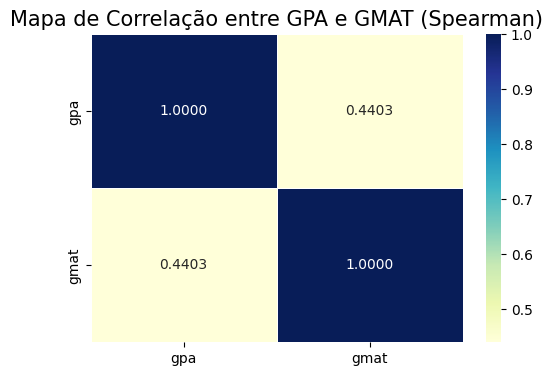

In [ ]:
# Criar a matriz de correlação usando Spearman apenas para gpa e gmat
correlacao = gpa_gmat[['gpa', 'gmat']].corr(method='spearman')

# Criar o heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(correlacao,
            annot=True, # Exibe os valores dentro das células
            cmap="YlGnBu", # Usa um gradiente de cores do amarelo ao azul
            fmt=".4f", # Formato os valores da esplendor com duas casas decimais
            linewidths=0.5) # Adiciona linhas divisórias no heatmap para melhor visualização

# Adicionar título
plt.title("Mapa de Correlação entre GPA e GMAT (Spearman)", fontsize=15)

# Exibir o gráfico
plt.show()

ANÁLISE DA RELAÇÃO ENTRE GPA GMAT

Correlação de Spearman:

- O coeficiente de Spearman de 0.4403 indica uma correlação positiva moderada entre GPA e GMAT. Ou seja, quando GMAT aumenta, GPA tende a aumentar também, mas essa relação não é forte.

- No gráfico, essa relação é visível porque a linha de regressão tem uma inclinação positiva, confirmando a tendência crescente, embora haja uma dispersão considerável dos pontos ao redor da linha. Isso justifica o coeficiente moderado.

P-valor

- O valor p de 0.0000 indica que a correlação é estatisticamente significativa.

- No gráfico, a inclinação positiva da linha de regressão indica a relação como valor p. Mesmo com a dispersão dos pontos, a tendência é estatisticamente significativa

#### Análise

- Existe uma relação estatisticamente significativa entre o GPA e o GMAT (p-valor=0.0000), embora não seja uma correlação muito forte (coeficiente de Spearman =0.4403). Isso sugere que o desempenho em um desses testes pode ter alguma influência sobre o outro, ou seja,  alunos que vão bem no GMAT tendem a ter um GPA mais alto, e vice-versa.

- Porém, com 0.4403, o GMAT sugere ser apenas um dos muitos fatores que influenciam o GPA. Sendo assim, não é possível prever o GPA de um aluno apenas avaliando o GMAT, ou seja, o desempenho em um teste tende a influenciar o outro, mas de forma limitada.

### 6. Existe alguma indústria em que a proporção dos candidatos admitidos é maior?

Definição dos grupos (cada setor da indústria)

filtrar apenas os admitidos


In [ ]:
consulting = df[df['trabalho_industria'] == 'Consulting']
pe_vc = df[df['trabalho_industria'] == 'PE/VC']
technology = df[df['trabalho_industria'] == 'Technology']
nonprofit = df[df['trabalho_industria'] == 'Nonprofit/Gov']
investment_banking = df[df['trabalho_industria'] == 'Investment Banking']
financial_services = df[df['trabalho_industria'] == 'Financial Services']
other = df[df['trabalho_industria'] == 'Other']
health_care  = df[df['trabalho_industria'] == 'Health Care']
investment_management = df[df['trabalho_industria'] == 'Investment Management']
cpg = df[df['trabalho_industria'] == 'CPG']
real_estate = df[df['trabalho_industria'] == 'Real Estate']
media_intertainment = df[df['trabalho_industria'] == 'Media/Entertainment']
retail = df[df['trabalho_industria'] == 'Retail']
energy = df[df['trabalho_industria'] == 'Energy']

Sucesso é considerado aqui o status "admitir" para os candidatos, que indiqca que a presença da admissão dos candidatos para cada um dos grupos (cada setor de indústria)

In [ ]:
sucessos_consulting = consulting['admissao'].value_counts().get('admitir', 0)
sucessos_pe_vc = pe_vc['admissao'].value_counts().get('admitir', 0)
sucessos_technology = technology['admissao'].value_counts().get('admitir', 0)
sucessos_nonprofit = nonprofit['admissao'].value_counts().get('admitir', 0)
sucessos_investment_banking = investment_banking['admissao'].value_counts().get('admitir', 0)
sucessos_financial_services = financial_services['admissao'].value_counts().get('admitir', 0)
sucessos_other = other['admissao'].value_counts().get('admitir', 0)
sucessos_health_care = health_care['admissao'].value_counts().get('admitir', 0)
sucessos_investment_management = investment_management['admissao'].value_counts().get('admitir', 0)
sucessos_cpg = cpg['admissao'].value_counts().get('admitir', 0)
sucessos_real_estate = real_estate['admissao'].value_counts().get('admitir', 0)
sucessos_media_intertainment = media_intertainment['admissao'].value_counts().get('admitir', 0)
sucessos_retail = retail['admissao'].value_counts().get('admitir', 0)
sucessos_energy = energy['admissao'].value_counts().get('admitir', 0)

Tamanho de cada um dos grupos (cada setor de indústria)

In [ ]:
nobs_consulting = df[df['trabalho_industria'] == 'Consulting'].shape[0]
nobs_pe_vc = df[df['trabalho_industria'] == 'PE/VC'].shape[0]
nobs_technology = df[df['trabalho_industria'] == 'Technology'].shape[0]
nobs_nonprofit = df[df['trabalho_industria'] == 'Nonprofit'].shape[0]
nobs_investment_banking = df[df['trabalho_industria'] == 'Investment Banking'].shape[0]
nobs_financial_services = df[df['trabalho_industria'] == 'Financial Services'].shape[0]
nobs_other = df[df['trabalho_industria'] == 'Other'].shape[0]
nobs_health_care = df[df['trabalho_industria'] == 'Health Care'].shape[0]
nobs_investment_management = df[df['trabalho_industria'] == 'Investment Management'].shape[0]
nobs_cpg = df[df['trabalho_industria'] == 'CPG'].shape[0]
nobs_real_estate = df[df['trabalho_industria'] == 'Real Estate'].shape[0]
nobs_media_intertainment = df[df['trabalho_industria'] == 'Media/Entertainment'].shape[0]
nobs_retail = df[df['trabalho_industria'] == 'Retail'].shape[0]
nobs_energy = df[df['trabalho_industria'] == 'Energy'].shape[0]

TESTE DE HOMOGENEIDADE

- Usado para comparar proporções em mais de dois grupos.
- Objetivo: Verificar se as proporções de uma característica são iguais em diferentes situações, ou seja, se possuem a mesma distribuição de uma característica.
- Esse teste será usado para comparar proporções em mais de dois grupos (neste caso, 14 indústrias ). Ele verifica se a proporção de candidatos admitidos é igual entre todos os setores ou se há diferenças importantes entre eles.

Exemplo:
- Pergunta: A proporção de candidatos admitidos é a mesma em todas as 14 indústrias?
- Dados: Para cada setor, você tem o número de candidatos admitidos e não admitidos
- Interpretação: comparar grupos diferentes para ver se eles seguem o mesmo padrão de atribuição


1. DEFINIÇÃO DAS HIPÓTESES

- H0: A proporção de candidatos admitidos é igual em todas as indústrias.

- H1:  Existe pelo menos uma indústria com uma proporção de admitidos significativamente diferente das demais



In [ ]:
# Estruturar os dados
proporcao_industrias = pd.DataFrame({
    'industria': [ # lista de indústrias
        'Consulting', 'PE_VC', 'Technology', 'Nonprofit', 'Investment_Banking',
        'Financial_Services', 'Other', 'Health_Care', 'Investment_Management',
        'CPG', 'Real_Estate', 'Media_Entertainment', 'Retail', 'Energy'
    ],
    'admitidos': [ # quantidade de candidatos admitidos
        sucessos_consulting, sucessos_pe_vc, sucessos_technology, sucessos_nonprofit,
        sucessos_investment_banking, sucessos_financial_services, sucessos_other,
        sucessos_health_care, sucessos_investment_management, sucessos_cpg,
        sucessos_real_estate, sucessos_media_intertainment, sucessos_retail, sucessos_energy
    ],
    'nao_admitidos': [ # quantidade de candidatos não admitidos
        max(nobs_consulting - sucessos_consulting, 0),
        max(nobs_pe_vc - sucessos_pe_vc, 0),
        max(nobs_technology - sucessos_technology, 0),
        max(nobs_nonprofit - sucessos_nonprofit, 0),
        max(nobs_investment_banking - sucessos_investment_banking, 0),
        max(nobs_financial_services - sucessos_financial_services, 0),
        max(nobs_other - sucessos_other, 0),
        max(nobs_health_care - sucessos_health_care, 0),
        max(nobs_investment_management - sucessos_investment_management, 0),
        max(nobs_cpg - sucessos_cpg, 0),
        max(nobs_real_estate - sucessos_real_estate, 0),
        max(nobs_media_intertainment - sucessos_media_intertainment, 0),
        max(nobs_retail - sucessos_retail, 0),
        max(nobs_energy - sucessos_energy, 0)
    ]
})

proporcao_industrias

,industria,admitidos,nao_admitidos
0,Consulting,224,1395
1,PE_VC,122,785
2,Technology,112,604
3,Nonprofit,89,0
4,Investment_Banking,82,498
5,Financial_Services,86,365
6,Other,57,364
7,Health_Care,40,294
8,Investment_Management,36,130
9,CPG,20,94


2. NÍVEL DE SIGNIFICÂNCIA

Probabilidade máxima tolerável pelo tomador de decisão para cometer o erro tipo I

In [ ]:
# Nível de significância
alpha = 0.05

In [ ]:
# Aplicar o teste Qui-Quadrado
chi2, p_prop_ind, _, _ = chi2_contingency(proporcao_industrias[['admitidos', 'nao_admitidos']])

# Exibir os resultados
print(f"Estatística Qui-Quadrado: {chi2:.4f}")
print(f"p-valor: {p_prop_ind:.4f}")

# Avaliação do p-valor
if p_prop_ind < alpha:
    print("Rejeitamos H0: Existe pelo menos uma indústria com uma proporção de admitidos significativamente maior.")
else:
    print("Não rejeitamos H0: Não há evidências suficientes de que a proporção de admitidos difere entre as indústrias.")

Estatística Qui-Quadrado: 494.7848
p-valor: 0.0000
Rejeitamos H0: Existe pelo menos uma indústria com uma proporção de admitidos significativamente maior.


Análise

- A estatística Qui-Quadrado (χ²) mede o quanto as proporções observadas variam das proporções esperadas em uma situação onde assumimos que não há diferenças reais entre os grupos (hipótese nula).

 - O valor muito alto (494,78) da estatística Qui-Quadrado mostra que as proporções de candidatos admitidos em cada setor são muito diferentes do que seria esperado. Quanto maior o χ², maior é a discrepância entre as proporções observadas e as esperadas.

- Considerando o p-valor em relação ao nível de significância, rejeitamos a hipótese nula, pois é < 0.05

- O p-valor mede a probabilidade de observar resultados, assumindo que a hipótese nula é verdadeira. Ou seja, quanto menor o p-valor, menor a chance de o resultado ser devido ao acaso , se H0 fosse verdadeiro.

 - Um p-valor de 0,0000 indica que é improvável que que as diferenças observadas tenham ocorrido por acaso. Ou seja, o p-valor é uma evidência contra H0

- A Análise é que existe pelo menos uma indústria com uma taxa de admissão significativamente diferente das outras .

PROPORÇÕES DE ADMITIDOS POR INDÚSTRIA

In [ ]:
proporcao_industrias['proporcao_admitidos'] = (
    (proporcao_industrias['admitidos'] /
     (proporcao_industrias['admitidos'] + proporcao_industrias['nao_admitidos'])) * 100
).round(2)

proporcao_industrias[['industria', 'proporcao_admitidos']]


,industria,proporcao_admitidos
0,Consulting,13.84
1,PE_VC,13.45
2,Technology,15.64
3,Nonprofit,100.00
4,Investment_Banking,14.14
5,Financial_Services,19.07
6,Other,13.54
7,Health_Care,11.98
8,Investment_Management,21.69
9,CPG,17.54


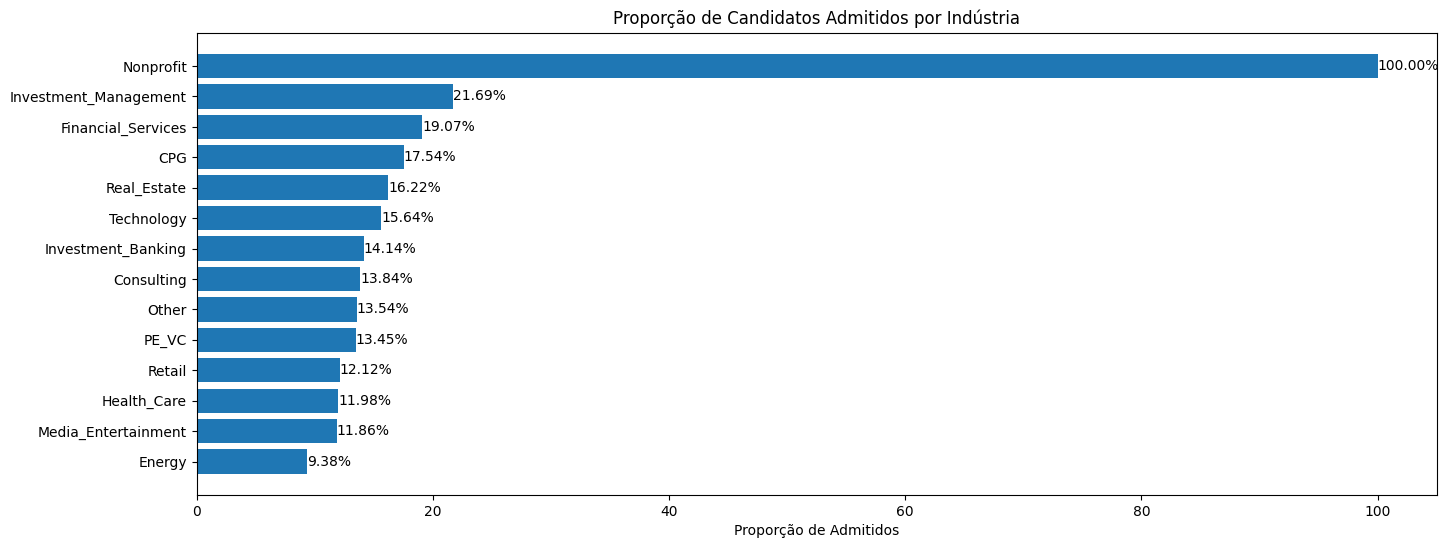

In [ ]:
# Ordenar os valores
proporcao_industrias = proporcao_industrias.sort_values(by='proporcao_admitidos', ascending=False)


# Criar o gráfico de barras horizontais
plt.figure(figsize=(16, 6))
plt.barh(proporcao_industrias['industria'], proporcao_industrias['proporcao_admitidos'], color='#1f77b4')
plt.xlabel('Proporção de Admitidos')
plt.title('Proporção de Candidatos Admitidos por Indústria')

# Adicionar os valores nas barras
for index, value in enumerate(proporcao_industrias['proporcao_admitidos']):
    plt.text(value + 0.005, index, f"{value:.2f}%", va='center', fontsize=10, color='black')

plt.gca().invert_yaxis()
plt.show()


Podemos observar que a indústria com maior proporção de admitidos é Nonprofit - Sem fins lucrativos, admitindo 100%, enquanto a menor é Energy - Energia, admitindo 9,38%.

### 7. Existe alguma correlação entre a experiência de trabalho e a admissão no programa de MBA?

1. DEFINIÇÃO DAS HIPÓTESES

- H0: existe correlação significativa entre experiência e admissão

- H1:  não existe correlação significativa entre experiência e admissão

In [ ]:
# Filtrar apenas os candidatos com valores válidos nas duas colunas
experiencia_admitidos = df[['experiencia', 'admissao']].dropna()

# Converter 'admissao' para valores numéricos (1 = Admitido, 0 = Não admitido)
experiencia_admitidos['admissao_bin'] = experiencia_admitidos['admissao'].apply(lambda x: 1 if x == 'admitir' else 0)

In [ ]:
# Calcular a correlação de Pearson
correlacao, p_valor = pearsonr(experiencia_admitidos['experiencia'], experiencia_admitidos['admissao_bin'])

# Exibir os resultados
print(f"Coeficiente de Correlação de Pearson: {correlacao:.4f}")
print(f"Valor p: {p_valor:.4f}")


Coeficiente de Correlação de Pearson: 0.0119
Valor p: 0.3504


In [ ]:
# Interpretação
if p_valor < 0.05:
    print("Rejeitamos H0: Existe correlação significativa entre experiência e admissão.")
else:
    print("Não rejeitamos H0: Não há evidências suficientes de correlação entre experiência e admissão.")

Não rejeitamos H0: Não há evidências suficientes de correlação entre experiência e admissão.


- O valor 0,0119 é muito próximo de 0 , praticamente nenhuma evidência entre as variáveis.

- Os resultados indicam não haver evidências estatísticas suficientes para afirmar que a experiência de trabalho influencia a admissão no programa de MBA . Ou seja, a experiência de trabalho e a admissão são praticamente independentes. Candidatos com mais experiência de trabalho não têm vantagem significativa sobre candidatos com menos experiência.

### 8. Dado que o candidato pertence a uma certa raça/etnia, qual a probabilidade dele ser admitido?

In [ ]:
# Contar o total de candidatos por raça
total_por_raca = df['raca'].value_counts()

# Contar os candidatos admitidos por raça
admitidos_por_raca = df[df['admissao'] == 'admitir']['raca'].value_counts()

Calcular a probabiliade condicional


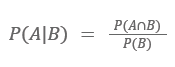

onde:
- P(A|B) = probabilidade do candidato ser admitido dada a raça/etnia
- P(A∩B) = número de admitidos na raça/etnia
- P(B) = probabilidade total de candidatos na raça/etnia

In [ ]:
probabilidade_admissao_por_raca = admitidos_por_raca / total_por_raca
print(probabilidade_admissao_por_raca)

raca
White       0.167582
Asian       0.165650
Black       0.087336
Hispanic    0.104027
Other       0.194093
Name: count, dtype: float64


### 9.1 Existe alguma relação entre gênero e notas para GPA e GMAT? Qual é a média de notas para cada gênero? Para o genero masculino, considerando apenas os admitidos, qual é a média do GMAT e GPA? E para o feminino?

RELAÇÃO ENTRE GÊNERO E NOTAS PARA GPA E GMAT PARA TODOS OS CANDIDATOS

In [ ]:
feminino_gmat = df[df['genero'] == 'Feminino']['gmat']
feminino_gpa = df[df['genero'] == 'Feminino']['gpa']
masculino_gmat = df[df['genero'] == 'Masculino']['gmat']
masculino_gpa = df[df['genero'] == 'Masculino']['gpa']

Verificar se há diferença significativa nas médias de GPA e GMAT entre os gêneros

DEFINIÇÃO DAS HIPÓTESES

- H0: Não há diferença significativa nas médias de GPA e GMAT entre os gêneros.

- H1:  Há uma diferença significativa nas médias de GPA e GMAT entre os gêneros.

Sendo assim, o tese de hipótese será bicaudal

NÍVEL DE SIGNIFICÂNCIA

Probabilidade máxima tolerável pelo tomador de decisão para cometer o erro tipo I

In [ ]:
# Nível de significância
alpha = 0.05

Comparar o p-valor com alfa (0,05):

- Se p-valor ≤ 0,05 -> Rejeitamos H0 -> Diferença entre as médias.

- Se p-valor > 0,05 -> Não rejeitamos H0 -> Não há evidências suficientes para afirmar que as médias são diferentes.

CALCULANDO O P-VALOR (GMAT)

Teste bicaudal:
p-valor = P(T # t)

ou seja, o p-valor será calculado pela probabilidade de um valor 'T" da distribuição ser diferente de um valor "t"

In [ ]:
estatistica_t_g, p_gmat_g = ttest_ind(feminino_gmat, masculino_gmat, equal_var=False)

print(f'A estatística t é: {estatistica_t_g:.4f}')
print(f'O p-value é: {p_gmat_g:.4f}')

A estatística t é: -1.8018
O p-value é: 0.0716


TOMADA DE DECISÃO (GMAT)

In [ ]:
# Nível de significância
if p_gmat_g < alpha:
    print("Rejeitamos a H0 para GMAT: Há evidências suficientes de que as médias são diferentes.")
else:
    print("Não rejeitamos a H0 para GMAT: Há evidências suficientes de que as médias são iguais.")

Não rejeitamos a H0 para GMAT: Há evidências suficientes de que as médias são iguais.


CALCULANDO O P-VALOR (GPA)

Teste bicaudal:
p-valor = P(T # t)

ou seja, o p-valor será calculado pela probabilidade de um valor 'T" da distribuição ser diferente de um valor "t"

In [ ]:
estatistica_t_g, p_gpa_g = ttest_ind(feminino_gpa, masculino_gpa, equal_var=False)

print(f'A estatística t é: {estatistica_t_g:.4f}')
print(f'O p-value é: {p_gpa_g:.4f}')

A estatística t é: -1.7376
O p-value é: 0.0824


TOMADA DE DECISÃO (GPA)

In [ ]:
# Nível de significância
if p_gpa_g < alpha:
    print("Rejeitamos a H0 para GPA: Há evidências suficientes de que as médias são diferentes.")
else:
    print("Não rejeitamos a H0 para GPA: Há evidências suficientes de que as médias são iguais.")

Não rejeitamos a H0 para GPA: Há evidências suficientes de que as médias são iguais.


- Análise GMAT

 - O p-valor (0.0716) é maior que 0.05, o que significa que não há evidências estatísticas suficientes para rejeitar a hipótese nula. Ou seja, não podemos afirmar que há uma diferença significativa nas notas de GMAT entre os gêneros. Porém, o valor está relativamente próximo de 0.05, o que pode indicar uma tendência de diferença entre os grupos, mas sem confirmação estatística forte.

- Análise GPA

 - O p-valor (0.0824) também é maior que 0.05, indicando que não há uma diferença estatisticamente significativa entre as médias de GPA para os gêneros. Assim como no GMAT, há uma leve indicação de diferença, mas não forte o suficiente para ser considerada significativa.


RELAÇÃO ENTRE GÊNERO E NOTAS PARA GPA E GMAT, CONSIDERANDO APENAS OS CANDIDATOS ADMITIDOS

In [ ]:
# Filtrar apenas os candidatos admitidos
df_admitidos = df[df['admissao'] == 'admitir']

# Criar um novo DataFrame 'gmat_gpa_genero_admitidos' sem modificar 'df'
gmat_gpa_genero_admitidos = df_admitidos.groupby('genero')[['gmat', 'gpa']].mean().round(2).reset_index()

# Renomear as colunas para 'gmat_media' e 'gpa_media'
gmat_gpa_genero_admitidos.rename(columns={'gmat': 'gmat_media', 'gpa': 'gpa_media'}, inplace=True)

# Exibir o DataFrame resultante
gmat_gpa_genero_admitidos


,genero,gmat_media,gpa_media
0,Feminino,682.84,3.33
1,Masculino,702.62,3.38


#### Análise

- Com base nesses resultados, não podemos afirmar que há uma relação estatisticamente significativa entre gênero e notas de GMAT/GPA.

### 9.2 Assumindo que uma diferença menor que 5% não é relevante, se GPA e GMAT fossem os principais determinantes para a admissão, existiria  alguma injustiça considerando os gêneros?

Se GPA e GMAT fossem os principais determinantes, as taxas de admissão para cada gênero deveriam ser proporcionais às suas médias de GPA e GMAT. Ou seja,  homens e mulheres com GPAs e GMATs semelhantes têm a mesma chance de serem admitidos? Se não tiverem, é sugestivo de injustiça, considerando os gêneros.

DEFINIÇÃO DAS HIPÓTESES

- H0: A taxa de admissão é proporcional às notas de GPA e GMAT

- H1:  Há disparidade na taxa de admissão entre os gêneros.

Sendo assim, o tese de hipótese será bicaudal

Antes de aplicar o teste, precisamos calcular:

- O número de candidatos admitidos por gênero.
- O número total de candidatos por gênero.
- A proporção de admitidos para cada gênero.

In [ ]:
# Filtrar candidatos admitidos
admitidos = df[df['admissao'] == 'admitir']

# Contar o número de admitidos e total de candidatos por gênero
tabela_genero = df.groupby('genero').agg(
    total_candidatos=('admissao', 'count'),
    admitidos=('admissao', lambda x: (x == 'admitir').sum())
).reset_index()

# Calcular a proporção de admitidos por gênero
tabela_genero['proporcao_admitidos'] = tabela_genero['admitidos'] / tabela_genero['total_candidatos']

# Exibir a tabela
tabela_genero.head()

,genero,total_candidatos,admitidos,proporcao_admitidos
0,Feminino,2251,450,0.199911
1,Masculino,3943,450,0.114126


Taxa de admissão
- feminina: 19, 99%
-  masculina: 11,41%

In [ ]:
# Filtrar a proporção de admitidos para o gênero
proporcao_feminino = tabela_genero.loc[tabela_genero['genero'] == 'Feminino', 'proporcao_admitidos'].values[0]
proporcao_masculino = tabela_genero.loc[tabela_genero['genero'] == 'Masculino', 'proporcao_admitidos'].values[0]

# Cálculo da diferença de proporção
diferenca_proporcao = proporcao_feminino - proporcao_masculino

# Exibir o resultado em percentual (duas casas decimais)
print(f'Diferença de Proporção: {diferenca_proporcao * 100:.2f}%')

Diferença de Proporção: 8.58%


A diferença é maior que 5%, o que, segundo o critério estabelecido, pode ser considerada relevante. Isso sugere uma possível disparidade de gênero nas taxas de admissão.

APLICANDO O TESTE DE PROPORÇÃO Z

O Teste de Proporção Z verifica se há uma diferença estatisticamente significativa entre as taxas de admissão de diferentes grupos (neste caso, gêneros). Ele compara as proporções de candidatos admitidos em relação ao total de candidatos de cada gênero.

In [ ]:
# Definir os valores para o teste
sucessos = tabela_genero['admitidos'].values  # Número de admitidos por gênero
nobs = tabela_genero['total_candidatos'].values  # Número total de candidatos por gênero

# Aplicar o teste de proporção Z
estatistica_z, p_valor = proportions_ztest(sucessos, nobs)

# Exibir os resultados
print(f"Estatística Z: {estatistica_z:.4f}")
print(f"p-valor: {p_valor:.4f}")


Estatística Z: 9.2148
p-valor: 0.0000


TOMADA DE DECISÃO

In [ ]:
# Interpretar o resultado
alpha = 0.05  # Nível de significância
if p_valor < alpha:
    print("Rejeitamos a hipótese nula: Existe uma diferença estatisticamente significativa na taxa de admissão entre os gêneros.")
else:
    print("Não rejeitamos a hipótese nula: Não há evidências estatísticas de diferença na taxa de admissão entre os gêneros.")

Rejeitamos a hipótese nula: Existe uma diferença estatisticamente significativa na taxa de admissão entre os gêneros.


ANÁLISE

- p-valor muito pequeno (p < 0,05) : Como p = 0.0000, isso significa que existe uma diferença estatisticamente significativa na taxa de admissão entre os gêneros. Por isso, rejeitamos a hipótese nula (H₀), que assume que as taxas de admissão para os gêneros são iguais.

- Estatística Z alta (9.2148): Quanto maior o valor de Z, maior a diferença entre as proporções em relação à variação esperada. Um valor de Z acima de 2 já indica uma diferença específica. Um Z de 9.2148 sugere que a discrepância entre as taxas de admissão é muito grande.

- A análise sugere que há uma diferença significativa nas taxas de admissão entre os gêneros , ou seja, um grupo está sendo admitido em maior proporção do que o outro.

### 10. A média de experiência de trabalho é diferente entre aprovados e não aprovados para cada um dos gêneros?

In [ ]:
# Filtrar candidatos masculinos
masc_aprovados = df[(df['genero'] == 'Masculino') & (df['admissao'] == 'admitir')]['experiencia']
masc_nao_aprovados = df[(df['genero'] == 'Masculino') & (df['admissao'] != 'admitir')]['experiencia']

# Filtrar candidatas femininas
fem_aprovadas = df[(df['genero'] == 'Feminino') & (df['admissao'] == 'admitir')]['experiencia']
fem_nao_aprovadas = df[(df['genero'] == 'Feminino') & (df['admissao'] != 'admitir')]['experiencia']


A formulação correta das hipóteses deve seguir a lógica do teste de hipóteses estatístico, que sempre assume a hipótese nula (H₀) como a ausência de efeito ou diferença, e a hipótese alternativa (H₁) como a existência de um efeito ou diferença.

DEFINIÇÃO DAS HIPÓTESES

H0: A média de experiência de trabalho é a mesma entre aprovados e não aprovados para cada um dos gêneros.

H1: A média de experiência de trabalho é diferente entre aprovados e não aprovados para cada um dos gêneros.

In [ ]:
# Nível de significância
alpha = 0.05

Comparar o p-valor com alfa (0,05):

- Se p-valor ≤ 0,05 -> Rejeitamos H0 -> Diferença entre as médias.

- Se p-valor > 0,05 -> Não rejeitamos H0 -> Não há evidências suficientes para afirmar que as médias são diferentes.

In [ ]:
# Teste t para candidatos do gênero masculino
t_masc, p_masc = stats.ttest_ind(masc_aprovados, masc_nao_aprovados, equal_var=False)
print(f"Masculino:")
print(f"Estatística t = {t_masc:.4f}")
print(f"p-valor = {p_masc:.4f}")

Masculino:
Estatística t = 0.4494
p-valor = 0.6533


In [ ]:
# Interpretar o resultado
alpha = 0.05  # Nível de significância
if p_masc < alpha:
    print("Rejeitamos a hipótese nula: Há diferença significativa nas médias de experiência entre aprovados e não aprovados para o gênero masculino.")
else:
    print("Não rejeitamos a hipótese nula: Não há diferença significativa nas médias de experiência entre aprovados e não aprovados para o gênero masculino.")

Não rejeitamos a hipótese nula: Não há diferença significativa nas médias de experiência entre aprovados e não aprovados para o gênero masculino.


In [ ]:
# Teste t para candidatas do gênero feminino
t_fem, p_fem = stats.ttest_ind(fem_aprovadas, fem_nao_aprovadas, equal_var=False)
print(f"Feminino:")
print(f"Estatística t = {t_fem:.4f}")
print(f"p-valor = {p_fem:.4f}")

Feminino:
Estatística t = 0.8138
p-valor = 0.4160


In [ ]:
# Interpretar o resultado
alpha = 0.05  # Nível de significância
if p_fem < alpha:
    print("Rejeitamos a hipótese nula: Há diferença significativa nas médias de experiência entre aprovados e não aprovados para o gênero feminino.")
else:
    print("Não rejeitamos a hipótese nula: Não há diferença significativa nas médias de experiência entre aprovados e não aprovados para o gênero feminino.")

Não rejeitamos a hipótese nula: Não há diferença significativa nas médias de experiência entre aprovados e não aprovados para o gênero feminino.


#### Análise

- Candidatos Masculinos

 - Estatística t = 0,4494: Diferença muito pequena entre as médias.

- Candidatas Femininas

 - Estatística t = 0,8138: Diferença pequena entre as médias.

- Para ambos os gêneros, o p-valor > 0.05, então não rejeitamos a hipótese nula. Isso significa que não há evidências estatísticas de que a experiência de trabalho afete a admissão no programa de MBA para nenhum dos gêneros.

- Se a experiência de trabalho fosse um fator determinante na aprovação, esperaríamos um p-valor menor que 0.05 e uma estatística t maior, indicando uma diferença significativa.


# **Síntese sobre os achados**

### Sobre o dataset

- 6.194 candidatos analisados, com 10 variáveis sobre perfil acadêmico, experiência profissional e resultado de admissão
- Única variável com valores ausentes relevantes: raca (29,74% de nulos) — dado que pode refletir recusa em autodeclarar
Nenhuma linha duplicada identificada

### Principais achados
1. Taxa de admissão por gênero
Candidatas do gênero feminino apresentaram taxa de admissão de aproximadamente 20%, enquanto candidatos do gênero masculino tiveram taxa de 11,4% — uma diferença expressiva que motivou a investigação de equidade.

2. GPA e GMAT não explicam sozinhos a diferença
Os testes t de Student indicaram que não há diferença estatisticamente significativa nas médias de GPA e GMAT entre admitidos e não admitidos, para nenhum dos gêneros (p-valor > 0,05 em todos os casos). Isso sugere que as notas acadêmicas, isoladamente, não são o fator determinante para a admissão.

3. Disparidade de admissão entre gêneros é estatisticamente significativa
O teste z de proporções revelou que a diferença nas taxas de admissão entre homens e mulheres é estatisticamente significativa (p-valor < 0,05), mesmo considerando candidatos com perfis acadêmicos semelhantes. Isso levanta questionamentos sobre os critérios de seleção além das notas.

4. Experiência de trabalho não diferencia admitidos por gênero
O teste t aplicado separadamente para cada gênero mostrou que a experiência profissional não apresenta diferença significativa entre admitidos e não admitidos — nem para homens (p = 0,6533) nem para mulheres (p = 0,4160).

5. Correlações entre variáveis numéricas
As correlações de Pearson e Spearman indicaram associação fraca entre GPA, GMAT e experiência de trabalho com a decisão de admissão, reforçando que outros fatores não capturados pelo dataset podem estar influenciando o resultado.

### Considerações finais
- A análise exploratória evidencia que o processo seletivo para o MBA analisado não se explica plenamente pelas variáveis acadêmicas e de experiência disponíveis. A diferença nas taxas de admissão entre gêneros, estatisticamente confirmada, sugere a necessidade de investigação mais aprofundada sobre os critérios de seleção — especialmente se o objetivo institucional inclui equidade de acesso.